This Notebook provides an example of the MaskedDiffusionLanguageModel's ability to model some elementary data.

In [1]:
using Random, StatsBase, Flux, OneHotArrays, Distributions, Plots, Random, StatsPlots, LaTeXStrings
using Flux
using NNlib
using Random
using LinearAlgebra

include("diffusion.jl")
include("loss.jl")
include("Diffusions.jl/src/maskedarrays.jl")

rng = Random.default_rng()

TaskLocalRNG()

# Helper Functions

In [2]:
# This function runs into errors due to the Process type defined in Diffusions.jl
# Therefore, it is called here once again to resolve this error
# This problem will disappear when the MaskedDiffusionLanguageModels are integrated into the package
using Random, StatsBase, Flux, OneHotArrays, Distributions, Plots, Random, StatsPlots, LaTeXStrings
rng = Random.default_rng()
using Random
using Flux
using NNlib
using Random
using LinearAlgebra


function sampleforward(rng::AbstractRNG, process::Process, t::Real, x::AbstractArray)
    x = copy(x)
    maskedvec(x) .= _sampleforward(rng, process, t, maskedvec(x))
    return x
end

function sampleforward(rng::AbstractRNG, process::Process, t::AbstractVector{<:Real}, x::AbstractArray)
    x = copy(x)
    for i in axes(x, ndims(x))
        maskedvec(x, i) .= _sampleforward(rng, process, t[i], maskedvec(x, i))
    end
    return x
end


sampleforward (generic function with 2 methods)

In [3]:
#import Diffusions: eq_dist
eq_dist(model::MaskedDiffusionLanguageModel) = Categorical(model.vocab_size)

eq_dist (generic function with 1 method)

In [4]:
# These functions run into the same problems as the ones mentioned above

#import Diffusions: samplebackward

function checktimesteps(timesteps)
    length(timesteps) ≥ 2 || throw(ArgumentError("timesteps must have at least two timesteps"))
    issorted(timesteps) || throw(ArgumentError("timesteps must be increasing"))
    all(>(0), timesteps) || throw(ArgumentError("all timesteps must be positive"))
end

struct NullTracker end

track!(::NullTracker, t, x, x0) = nothing


struct Tracker
    time::Vector
    data::Vector
    x0::Vector
end

Tracker() = Tracker([], [], [])

function track!(tracker::Tracker, t, x, x0)
    push!(tracker.time, t)
    push!(tracker.data, x)
    push!(tracker.x0, x0)
    return nothing
end


function samplebackward(rng::AbstractRNG, guess, process, timesteps, x; tracker=NullTracker())
    checktimesteps(timesteps)
    i = lastindex(timesteps)
    t = timesteps[i]
    while i > firstindex(timesteps)
        s = timesteps[i-1]
        x_0 = guess(x, t)
        x = endpoint_conditioned_sample(rng, process, s, t, x_0, x)
        # @show x
        # track!(tracker, s, x, x_0)
        t = s
        i -= 1
    end
    return x
end

samplebackward (generic function with 1 method)

In [5]:
function endpoint_conditioned_sample(rng::AbstractRNG, process::Process, s::Real, t::Real, x_0::AbstractArray, x_t::AbstractArray)
    if x_t isa MaskedArray
        # x_0 inherits masked elements from x_t
        x_0 = MaskedArray(x_0, x_t.indices)
    end
    x = copy(x_t)
    maskedvec(x) .= _endpoint_conditioned_sample(rng, process, s, t, maskedvec(x_0), maskedvec(x_t))
    return x
end

endpoint_conditioned_sample(rng::AbstractRNG, process, s::Real, t::Real, x_0, x_t) =
    endpoint_conditioned_sample.(rng, process, s, t, x_0, x_t)

# sample x at time s conditioned on x_0 at time 0 and x_t at time t
endpoint_conditioned_sample(P::Process, s::Real, t::Real, x_0, x_t) = endpoint_conditioned_sample(Random.default_rng(), P, s, t, x_0, x_t)


endpoint_conditioned_sample (generic function with 3 methods)

# Data stuff

In [6]:
directory = "antibody_data/unfiltered_data/"
filtered_dir = "antibody_data/filtered_data/"
filter_parameters = ["complete_vdj" "productive" "stop_codon" "v_frameshift" "vj_in_frame"; false false true true false] #2D array of headers we want to filter and what value to filter away


2×5 Matrix{Any}:
      "complete_vdj"       "productive"  …       "vj_in_frame"
 false                false                 false

## No Padding

In [ ]:
##Quick claude code

using DataStructures

# Step 1: Create amino acid to index mapping
function create_aa_to_index(file_paths)
    unique_aas = Set{Char}()
    for file in file_paths
        
        open(file, "r") do f
            for line in eachline(f)
                union!(unique_aas, Set(line))
            end
        end
    end
    unique_aas = sort(collect(unique_aas))
    return Dict(aa => i for (i, aa) in enumerate(unique_aas))
end

# Step 2: Sequence to indices conversion
function seq_to_indices(seq, aa_to_index)
    return [get(aa_to_index, aa, 1) for aa in seq]  # Use 1 as default if aa not found
end

# Step 3: Data loader
struct SequenceDataLoader
    file_paths::Vector{String}
    aa_to_index::Dict{Char, Int}
    batch_size::Int
    sequence_length::Int
    alph::Int
end

function Base.iterate(loader::SequenceDataLoader, state=(1, 1))
    file_idx, line_idx = state
    batch = []
    
    while length(batch) < loader.batch_size
        if file_idx > length(loader.file_paths)
            return nothing
        end
        
        open(loader.file_paths[file_idx], "r") do f
            for _ in 1:line_idx-1
                readline(f)
            end
            
            while length(batch) < loader.batch_size
                line = readline(f)
                if eof(f)
                    file_idx += 1
                    line_idx = 1
                    break
                end
                
                push!(batch, seq_to_indices(line, loader.aa_to_index))
                line_idx += 1
            end
        end
    end
    
    # Convert batch to 3D array: (vocab_size, seq_length, batch_size)
    x = zeros(Int, loader.sequence_length, loader.batch_size)
    for (i, seq) in enumerate(batch)
        x[:, i] = seq
    end
    #println(length(loader.aa_to_index))
    return (onehotbatch(x, 1:length(loader.aa_to_index)+1), (file_idx, line_idx))
end


In [ ]:
batch_size = 1
# Usage
filtered_data = readdir(filtered_dir)

file_path::Vector{String} = filtered_dir .* filtered_data

aa_to_index = create_aa_to_index(file_path[2:end])

# Determine the alphabet size
@show alph = length(aa_to_index)

seq_len = Int(target_length)

data_loader = SequenceDataLoader(file_path[2:end], aa_to_index, batch_size, seq_len, alph)

## Padding

In [7]:
# Step 1: Create amino acid to index mapping
function create_aa_to_index(file_paths)
    unique_aas = Set{Char}()
    for file_path in file_paths
        open(file_path, "r") do f
            for line in eachline(f)
                union!(unique_aas, Set(line))
            end
        end
    end
    unique_aas = sort(collect(unique_aas))
    return Dict(aa => i for (i, aa) in enumerate(unique_aas))
end

# Step 2: Sequence to indices conversion
function seq_to_indices(seq, aa_to_index)
    return [get(aa_to_index, aa, 1) for aa in seq]  # Use 1 as default if aa not found
end

# Step 3: Data loader
struct SequenceDataLoader
    file_paths::Vector{String}
    aa_to_index::Dict{Char, Int}
    batch_size::Int
    alph::Int
    max_sequence_length::Int
end

# Constructor
function SequenceDataLoader(file_paths, aa_to_index, batch_size)
    alph = length(aa_to_index)
    max_sequence_length = 0
    for file_path in file_paths
        open(file_path, "r") do f
            for line in eachline(f)
                max_sequence_length = max(max_sequence_length, length(line))
            end
        end
    end
    return SequenceDataLoader(file_paths, aa_to_index, batch_size, alph, max_sequence_length)
end

function Base.iterate(loader::SequenceDataLoader, state=(1, 1))
    file_idx, line_idx = state
    batch = []
    
    while length(batch) < loader.batch_size
        if file_idx > length(loader.file_paths)
            return nothing
        end
        
        open(loader.file_paths[file_idx], "r") do f
            for _ in 1:line_idx-1
                readline(f)
            end
            
            while length(batch) < loader.batch_size
                line = readline(f)
                if eof(f)
                    file_idx += 1
                    line_idx = 1
                    break
                end
                
                push!(batch, seq_to_indices(line, loader.aa_to_index))
                line_idx += 1
            end
        end
    end
    
    # Pad sequences and convert batch to 3D array: (vocab_size, max_seq_length, batch_size)
    x = zeros(Int, loader.max_sequence_length, loader.batch_size)
    for (i, seq) in enumerate(batch)
       
        x[1:length(seq), i] = seq
    end
    
    return (onehotbatch(x, 0:loader.alph+1), (file_idx, line_idx))
end

In [8]:
batch_size = 8
# Usage
filtered_data = readdir(filtered_dir)

file_path::Vector{String} = filtered_dir .* filtered_data

aa_to_index = create_aa_to_index(file_path[2:end])

# Determine the alphabet size
@show alph = length(aa_to_index)

data_loader = SequenceDataLoader(file_path[2:end], aa_to_index, batch_size)

seq_len = data_loader.max_sequence_length

alph = length(aa_to_index) = 21


164

# version 3

In [9]:
using Flux: Scale, _size_check, ChainRulesCore
import Flux: LayerNorm
 
function (a::LayerNorm)(x::AbstractArray)
    ChainRulesCore.@ignore_derivatives if a.diag isa Scale
      for d in 1:ndims(a.diag.scale)
        _size_check(a, x, d => size(a.diag.scale, d))
      end
    end
    eps = convert(float(eltype(x)), a.ϵ)  # avoids promotion for Float16 data, but should ε chage too?
    a.diag(normalise(x; dims=1:length(a.size), eps))
end
 
function normalise(x::AbstractArray; dims=ndims(x), eps = 1f-3)
    ε = eps^2 
    μ = Flux.mean(x, dims=dims)
    v = Flux.var(x, dims=dims, mean=μ, corrected=false)
    return  (x .- μ) ./ (sqrt.(v .+ ε))
end

normalise (generic function with 1 method)

In [10]:
#Version 3

using Flux, Functors
using NeuralAttentionlib
using NeuralAttentionlib: multihead_qkv_attention, CausalMask, with_rotary_position_embedding

struct TimestepEmbedder
    mlp::Chain
    freqs::Vector{Float32}
end

#Functors.@functor TimestepEmbedder

function TimestepEmbedder(dim::Int; max_period::Float32 = 10000f0)
    half = div(dim, 2)
    freqs = exp.(-log(max_period) * Float32.(range(0, 1, length=half)) / half)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, relu),
            Dense(dim * 4, dim)
        ),
        freqs
    )
end

function timestep_embedding(t::Real, freqs::Vector{Float32})
    args = t .* freqs
    embedding = vcat(sin.(args), cos.(args))
    if length(freqs) * 2 < length(embedding)
        embedding = vcat(embedding, zero(t))
    end
    return Float32.(embedding)
end

function (te::TimestepEmbedder)(t::Real)
    t_freq = timestep_embedding(t, te.freqs)
    return te.mlp(t_freq)
end

struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

Functors.@functor AdaLN

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end

struct MultiheadAttention{Q,K,V,O}
    head::Int
    future::Bool
    iqproj::Q
    ikproj::K
    ivproj::V
    oproj::O
    rope_dim::Int
end

Functors.@functor MultiheadAttention (iqproj, ikproj, ivproj, oproj)

function MultiheadAttention(head, hidden_size, head_size; future = true)
    MultiheadAttention(head, future,
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(head_size * head, hidden_size),
        head_size
    )
end

function (mha::MultiheadAttention)(q, k, v)
    qkv_attention = x -> multihead_qkv_attention(mha.head,
        mha.iqproj(x[1]), mha.ikproj(x[2]), mha.ivproj(x[3]),
        mha.future ? nothing : CausalMask())
    
    rotary_qkv_attention = x -> with_rotary_position_embedding(mha.rope_dim, qkv_attention(x))
    
    return mha.oproj(rotary_qkv_attention((q, k, v)))
end

struct TransformerLayer
    attention::MultiheadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

Functors.@functor TransformerLayer

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiheadAttention(n_head, dim, dim ÷ n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, c::AbstractVector)
    normalized = layer.norm1(x, c)
    attention_output = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    x = x + layer.ff(layer.norm2(x, c))
    return x
end

mutable struct DIT
    token_embed::Dense
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Functors.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::Real)
    x = model.token_embed(x)
    c = model.time_embed(t)
    
    for layer in model.layers
        x = layer(x, c)
    end
    
    x = model.final_norm(x, c)
    return model.final_layer(x)
end
println("done!")

done!


In [11]:
function test_dit_model_single_timestep()
    vocab_size = 5
    seq_len = 3
    dim = 128
    n_layers = 4
    n_heads = 8
    cond_dim = 64
    batch_size = 32

    model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim)
    x = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len, batch_size), 1:vocab_size))
    t1 = rand(Float32)
    t2 = rand(Float32)

    println("DIT model with single timestep test:")
    println("Input shape: ", size(x))
    println("Timestep 1: ", t1)
    println("Timestep 2: ", t2)

    # Test time embedding
    t_embed = model.time_embed(t1)
    println("Time embedding shape: ", size(t_embed))
    @assert size(t_embed) == (cond_dim,) "Time embedding size mismatch"

    # Test token embedding
    token_embed = model.token_embed(x)
    println("Token embedding shape: ", size(token_embed))
    @assert size(token_embed) == (dim, seq_len, batch_size) "Token embedding size mismatch"

    # Test full forward pass
    output1 = model(x, t1)
    println("Output 1 shape: ", size(output1))
    @assert size(output1) == (vocab_size, seq_len, batch_size) "Output size mismatch"

    output2 = model(x, t2)
    println("Output 2 shape: ", size(output2))
    @assert size(output2) == (vocab_size, seq_len, batch_size) "Output size mismatch"

    # Test that the output is different for different timesteps
    diff = sum(abs.(output1 - output2))
    println("Difference between outputs: ", diff)
    @assert diff > 1e-5 "Output should be different for different timesteps"

    println("DIT model with single timestep test passed!")
end

test_dit_model_single_timestep()

DIT model with single timestep test:
Input shape: (5, 3, 32)
Timestep 1: 0.3323934
Timestep 2: 0.5834765
Time embedding shape: (64,)
Token embedding shape: (128, 3, 32)
Output 1 shape: (5, 3, 32)
Output 2 shape: (5, 3, 32)
Difference between outputs: 130.50107
DIT model with single timestep test passed!


In [ ]:
function test_rope_effectiveness()
    vocab_size = 5
    seq_len = 10  # Longer sequence to better test positional effects
    dim = 128
    n_layers = 4
    n_heads = 8
    cond_dim = 64
    batch_size = 1  # Use batch size 1 for this test

    model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim)
    
    # Create two identical sequences, but shifted
    x1 = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len), 1:vocab_size))
    x2 = circshift(x1, (0, 5))  # Shift the sequence by 5 positions
    
    t = rand(Float32)

    output1 = model(x1, t)
    output2 = model(x2, t)

    # Check if outputs are different
    diff = sum(abs.(output1 - output2))
    println("Difference between shifted outputs: ", diff)
    @assert diff > 1e-5 "Outputs should be different for shifted inputs"

    println("RoPE effectiveness test passed!")
end

test_rope_effectiveness()

# Transformer Training

In [12]:
# Get a sample batch to determine the maximum sequence length

# sample_batch = sample_sequences(df, batch_size, aa_to_index, alph)
# seq_len, batch_size = size(sample_batch)[2:3]
max_seq_len = data_loader.max_sequence_length

vocab_size = alph + 2 # +2 if using padding, otherwise + 1

dim = 128  # or whatever dimension you prefer
n_layers = 4 # adjust as needed
n_heads = 8 # adjust as needed
cond_dim = 128  # adjust as needed

model = DIT(vocab_size, max_seq_len, dim, n_layers, n_heads, cond_dim);

In [13]:
using InverseFunctions: inverse, square
include("Diffusions.jl/src/utils.jl")
timesteps = timeschedule(exp, Float32(0.001),Float32(1.0),100)
cumu_loss = 0
training_losses = []

Any[]

In [14]:
P = MaskedDiffusionLanguageModel(vocab_size, vocab_size, cosineschedule)

opt = Flux.Optimiser(WeightDecay(0.0001), Adam(0.01))#Adam(0.001))
params = Flux.params(model);

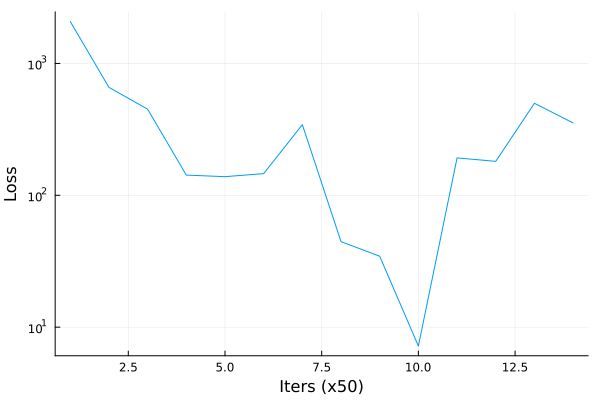

In [ ]:
println("atleast line 1")
for iter in 1:5000000
    # Get a batch from the data loader
    batch = iterate(data_loader)
    

    if batch === nothing
        # Restart the data loader if we've gone through all data
        data_loader = SequenceDataLoader(file_paths, aa_to_index, batch_size)
        batch = iterate(data_loader)
    end
    x, _ = batch

  
    T = rand(timesteps)
    diffusedOH = sampleforward(rng, P, T, x)
 
    # Forward pass and loss computation
    loss, grads = Flux.withgradient(params) do
        output = model(diffusedOH, T)
        -standardloss(P, T, output, x)[1]
    end
    
    # Update parameters
    Flux.update!(opt, params, grads)
    
    iter_modif = 50
    epsilon = 1e-10
    cumu_loss += loss
    if mod(iter,iter_modif) == 0
        opt[2].eta = opt[2].eta * 0.997
        push!(training_losses, cumu_loss/iter_modif)  
        cumu_loss = 0.0
        IJulia.clear_output(true)
        try
        filtered_losses = [max(loss, epsilon) for loss in training_losses]
        plot(filtered_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x$iter_modif)", label = :none) |> IJulia.display
    catch e
        println("Error in plotting: ", e)
    end
        #plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x$iter_modif)", label = :none) |> IJulia.display
        sleep(0.01)
    end
end
IJulia.clear_output(true)
plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x$iter_modif)", label = :none)

# Evaluation

In [ ]:
# WITH PADDING!!!

function zero_sample(x_t, t)
    vocab_size, seq_length, batch_size = size(x_t)
    
    # Ensure vocab_size is correct
    @assert vocab_size == alph + 2 "Vocabulary size mismatch"
    
    sm = softmax(model(x_t, t))
    sampled = zeros(Bool, vocab_size, seq_length, batch_size)
    
    for b in 1:batch_size
        for s in 1:seq_length
            probs = sm[:, s, b]
            sampled_token = rand(Categorical(probs)) - 1  # Subtract 1 to shift range to 0:21
            # Use 0:alph+1 to match the range in sample_sequences
            sampled[:, s, b] = onehotbatch([sampled_token], 0:alph+1)
        end
    end
    
    return sampled
end


In [ ]:
N = 10 # Number of samples
#seq_length = size(sample_sequences(df, batch_size, aa_to_index, alph), 2) # or use seq_len as defined above
seq_length = seq_len
# Initialize x_T with all tokens set to the mask token index (alph + 1)
x_T = falses(vocab_size, seq_length, N)
x_T[end, :, :] .= true

@time generated_samples = samplebackward(rng, zero_sample, P, timesteps, x_T);

In [ ]:
using Plots
using StatsBase

# Function to convert one-hot encoded data back to sequences
function onehot_to_seq(onehot_data, aa_to_index)
    index_to_aa = Dict(v => k for (k, v) in aa_to_index)
    index_to_aa[0] = '-'  # Padding
    index_to_aa[length(aa_to_index) + 1] = 'X'  # Mask token
    seqs = []
    for i in 1:size(onehot_data, 3)
        seq = [index_to_aa[argmax(onehot_data[:, j, i]) - 1] for j in 1:size(onehot_data, 2)]
        push!(seqs, join(seq))
    end
    return seqs
end

# Function to read sequences from file
function read_sequences_from_file(file_path)
    open(file_path, "r") do file
        return [strip(line) for line in eachline(file)]
    end
end

file_paths = file_path[2:end]

aa_to_index = create_aa_to_index(file_paths)

generated_samples = # Your generated samples here

# Convert generated samples to sequences
generated_seqs = onehot_to_seq(generated_samples, aa_to_index)

function remove_trailing_dashes(arr)
    return map(arr) do str
        rstrip(str, '-')
    end
end

stripped_generated_seqs = remove_trailing_dashes(generated_seqs)

# Read original sequences from the first file (you can modify this if needed)
original_seqs = read_sequences_from_file(file_paths[1])

# Limit original sequences to match the number of generated sequences
original_seqs = original_seqs[1:min(length(generated_seqs), length(original_seqs))]

# The rest of the functions remain the same

# 1. Sequence length distribution
function plot_length_distribution(gen_seqs, orig_seqs)
    gen_lengths = length.(gen_seqs)
    orig_lengths = length.(orig_seqs)
    p = histogram(gen_lengths, bins=20, alpha=0.5, label="Generated", normalize=:probability)
    histogram!(p, orig_lengths, bins=20, alpha=0.5, label="Original", normalize=:probability)
    title!("Sequence Length Distribution")
    xlabel!("Sequence Length")
    ylabel!("Frequency")
    return p
end

p1 = plot_length_distribution(stripped_generated_seqs, original_seqs)
display(p1)

# 2. Amino acid frequency
function plot_aa_frequency(gen_seqs, orig_seqs)
    gen_aa_freq = countmap(vcat(collect.(gen_seqs)...))
    orig_aa_freq = countmap(vcat(collect.(orig_seqs)...))
    all_aas = sort(unique(vcat(collect(keys(gen_aa_freq)), collect(keys(orig_aa_freq)))))
    
    gen_freqs = [get(gen_aa_freq, aa, 0) for aa in all_aas]
    orig_freqs = [get(orig_aa_freq, aa, 0) for aa in all_aas]
    
    p = bar(string.(all_aas), gen_freqs ./ sum(gen_freqs), alpha=0.5, label="Generated")
    bar!(p, string.(all_aas), orig_freqs ./ sum(orig_freqs), alpha=0.5, label="Original")
    title!("Amino Acid Frequency")
    xlabel!("Amino Acid")
    ylabel!("Relative Frequency")
    return p
end

p2 = plot_aa_frequency(generated_seqs, original_seqs)
display(p2)

# 3. Position-specific amino acid frequency
function plot_position_aa_freq(seqs, title)
    max_len = maximum(length.(seqs))
    unique_aas = sort(unique(vcat(collect.(seqs)...)))
    aa_freq = zeros(Int, length(unique_aas), max_len)
    for (i, seq) in enumerate(seqs)
        for (j, aa) in enumerate(seq)
            aa_freq[findfirst(==(aa), unique_aas), j] += 1
        end
    end
    aa_freq = aa_freq ./ sum(aa_freq, dims=1)
    heatmap(1:max_len, string.(unique_aas), aa_freq, 
            color=:viridis, title=title, xlabel="Position", ylabel="Amino Acid")
end

p3 = plot_position_aa_freq(generated_seqs, "Generated Position-Specific AA Frequency")
display(p3)
p4 = plot_position_aa_freq(original_seqs, "Original Position-Specific AA Frequency")
display(p4)

# 4. Visualization of generated sequences
function visualize_sequences(seqs, n=10)
    n = min(n, length(seqs))
    seqs_matrix = permutedims(hcat([collect(seq) for seq in seqs[1:n]]...))
    heatmap(seqs_matrix, 
            colorbar=false, 
            title="Generated Sequences", 
            xlabel="Position", 
            ylabel="Sequence",
            size=(800, 30*n),
            aspect_ratio=:equal,
            xticks=1:size(seqs_matrix, 2),
            yticks=(1:size(seqs_matrix, 1), 1:size(seqs_matrix, 1)))
end

p5 = visualize_sequences(generated_seqs)
display(p5)

# 5. Sequence complexity (Shannon entropy)
function sequence_entropy(seq)
    freq = countmap(seq)
    probs = values(freq) ./ length(seq)
    return -sum(p * log2(p) for p in probs)
end

function plot_sequence_complexity(gen_seqs, orig_seqs)
    gen_entropy = [sequence_entropy(seq) for seq in gen_seqs]
    orig_entropy = [sequence_entropy(seq) for seq in orig_seqs]
    p = histogram(gen_entropy, bins=20, alpha=0.5, label="Generated", normalize=:probability)
    histogram!(p, orig_entropy, bins=20, alpha=0.5, label="Original", normalize=:probability)
    title!("Sequence Complexity Distribution")
    xlabel!("Shannon Entropy")
    ylabel!("Frequency")
    return p
end

p6 = plot_sequence_complexity(generated_seqs, original_seqs)
display(p6)

# 6. Basic quantitative metrics
function compute_basic_metrics(gen_seqs, orig_seqs)
    avg_len_gen = mean(length.(gen_seqs))
    avg_len_orig = mean(length.(orig_seqs))
    aa_diversity_gen = mean(length.(unique.(gen_seqs)))
    aa_diversity_orig = mean(length.(unique.(orig_seqs)))
    
    avg_entropy_gen = mean(sequence_entropy.(gen_seqs))
    avg_entropy_orig = mean(sequence_entropy.(orig_seqs))
    
    println("Average sequence length (generated): ", round(avg_len_gen, digits=2))
    println("Average sequence length (original): ", round(avg_len_orig, digits=2))
    println("Average amino acid diversity (generated): ", round(aa_diversity_gen, digits=2))
    println("Average amino acid diversity (original): ", round(aa_diversity_orig, digits=2))
    println("Average sequence entropy (generated): ", round(avg_entropy_gen, digits=2))
    println("Average sequence entropy (original): ", round(avg_entropy_orig, digits=2))
end

compute_basic_metrics(generated_seqs, original_seqs)

In [ ]:
for i in eachindex(stripped_generated_seqs)
    println(stripped_generated_seqs[i])
end

In [ ]:
for i in eachindex(stripped_generated_seqs)
    println(generated_seqs[i])
end